
<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 3: Clasificación con una Red Neuronal Profunda con TensorFlow y Pytorch</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Construir, entrenar y evaluar un MLP profundo en TensorFlow y Pytorch sobre un conjunto de datos real, aplicando las técnicas vistas (regularización, optimizadores, curvas de aprendizaje).
</div>


### Instrucciones

Trabajaremos con el dataset de imágenes **CIFAR-10**: 60 000 imágenes a color de $32\times32$ píxeles (50 000 de entrenamiento y 10 000 de prueba) repartidas en **10 clases** (avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión). Está disponible de forma nativa tanto en TensorFlow (`keras.datasets.cifar10`) como en PyTorch (`torchvision.datasets.CIFAR10`).

1. **Carga y explora** el dataset: normaliza los píxeles a $[0, 1]$, **aplana** cada imagen a un vector de $32\times32\times3 = 3072$ valores (para el MLP) y **visualiza** algunos ejemplos con su clase.
2. Divide en train/validación y usa el conjunto de prueba oficial.
3. Construye un **MLP profundo con Tensorflow** (**Modelo 1**): al menos 3 capas ocultas, con `BatchNormalization`, `Dropout` y optimizador **Adam**. Define la entrada con `keras.Input(shape=(3072,))`. Entrena y reporta la precisión en test.
4. Construye el **mismo MLP con PyTorch** (**Modelo 2**): entrena con **AdamW** y un **scheduler** de tu elección (p. ej. `StepLR` o `CosineAnnealingLR`).
5. Grafica las **curvas de aprendizaje** (pérdida y precisión) de ambos modelos y reporta la **precisión en test**.
6. Muestra la **matriz de confusión** e identifica qué clases se confunden más.
7. **Compara** ambas implementaciones y anota tus conclusiones.

> un MLP sobre imágenes a color suele alcanzar ~45–55 % de precisión en CIFAR-10. Es un buen punto de partida para motivar el uso de **redes convolucionales (CNN)** más adelante.


### 0. Carga y exploración del dataset (CIFAR-10)

Esta parte ya está resuelta: carga el dataset, lo normaliza, lo aplana y muestra algunos ejemplos. Reutilizarás estas variables (`X_train`, `y_train`, `X_test`, `y_test`) en ambos modelos.

Entrenamiento: (50000, 3072) | Prueba: (10000, 3072)
[0 1 2 3 4 5 6 7 8 9]


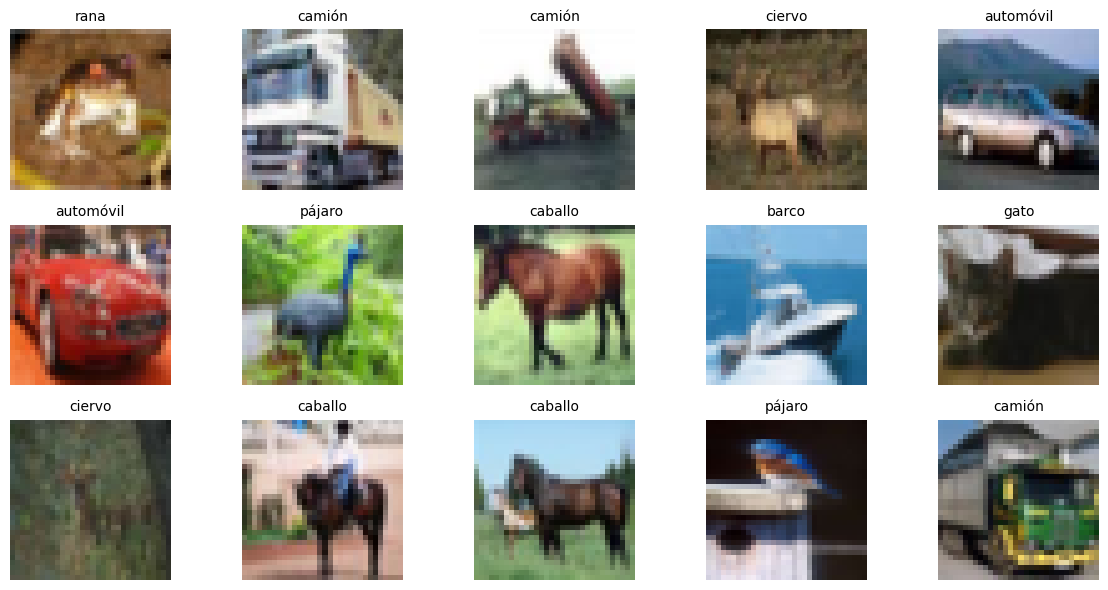

In [1]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Nombres de las 10 clases de CIFAR-10
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Cargar el dataset (imágenes 32x32x3, etiquetas 0-9)
(X_train_img, y_train), (X_test_img, y_test) = cifar10.load_data()
y_train, y_test = y_train.ravel(), y_test.ravel()   # de (N,1) a (N,)

# Normalizar a [0,1] y aplanar a vectores de 3072 (para el MLP)
X_train = (X_train_img / 255.0).reshape(-1, 32 * 32 * 3).astype('float32')
X_test  = (X_test_img  / 255.0).reshape(-1, 32 * 32 * 3).astype('float32')

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)
print('Clases:', np.unique(y_train))

# Visualizar 15 imágenes con su clase
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train_img[i])          # imagen original a color
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

### 1. Modelo con TensorFlow

In [2]:
import tensorflow as tf

# 1. Construcción del MLP profundo con la API Sequential
model_tf = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(3072,)),
    
    # Capa oculta 1
    tf.keras.layers.Dense(512),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.3),
    
    # Capa oculta 2
    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.3),
    
    # Capa oculta 3
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2),
    
    # Capa de salida
    tf.keras.layers.Dense(10, activation='softmax')
])

# 2. Compilar el modelo
model_tf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_tf.summary()

# 3. Entrenar reservando 10% para validación
history_tf = model_tf.fit(
    X_train, y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# 4. Evaluar en test
test_loss_tf, test_acc_tf = model_tf.evaluate(X_test, y_test, verbose=0)
print(f"\n[TensorFlow] Precisión en el conjunto de prueba: {test_acc_tf * 100:.2f}%")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,742,474 (6.65 MB)

 Trainable params: 1,740,682 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 52s 53ms/step - accuracy: 0.3477 - loss: 1.8301 - val_accuracy: 0.3508 - val_loss: 1.7857
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.4286 - loss: 1.5970 - val_accuracy: 0.4098 - val_loss: 1.6580
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.4603 - loss: 1.5111 - val_accuracy: 0.4362 - val_loss: 1.5749
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.4794 - loss: 1.4533 - val_accuracy: 0.4376 - val_loss: 1.5652
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.4982 - loss: 1.4054 - val_accuracy: 0.4836 - val_loss: 1.4569
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.5153 - loss: 1.3627 - val_accuracy: 0.3466 - val_loss: 1.8524
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.5263 - loss: 1.3312 - val_accuracy: 0.4578 - val_loss: 1.5214
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.5336 - loss: 1.2970 - 

### 2. Modelo con Pytorch

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convertir datos a tensores de PyTorch
X_t = torch.tensor(X_train, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# 1. Separar 10% para validación (45,000 train / 5,000 validation)
dataset_full = TensorDataset(X_t, y_t)
val_size = int(len(dataset_full) * 0.1)
train_size = len(dataset_full) - val_size
train_ds, val_ds = random_split(dataset_full, [train_size, val_size])

test_ds = TensorDataset(X_test_t, y_test_t)

# 2. Crear DataLoaders
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print('Tensores listos:', X_t.shape, X_test_t.shape, '| Dispositivo:', device)

Tensores listos: torch.Size([50000, 3072]) torch.Size([10000, 3072]) | Dispositivo: cpu


In [4]:
class MiMLP(nn.Module):
    def __init__(self, num_features=3072, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            # Capa oculta 1
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Capa oculta 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Capa oculta 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Capa de salida (Logits)
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model_pt = MiMLP().to(device)

In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_pt.parameters(), lr=1e-3, weight_decay=1e-2)
epochs = 25
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

history_pt = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # --- Entrenamiento ---
    model_pt.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model_pt(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    scheduler.step()
    
    epoch_train_loss = running_loss / train_size
    epoch_train_acc = correct / total

    # --- Validación ---
    model_pt.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model_pt(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()
            
    epoch_val_loss = val_loss / val_size
    epoch_val_acc = val_correct / val_total
    
    history_pt['train_loss'].append(epoch_train_loss)
    history_pt['val_loss'].append(epoch_val_loss)
    history_pt['train_acc'].append(epoch_train_acc)
    history_pt['val_acc'].append(epoch_val_acc)
    
    print(f"Época {epoch+1:02d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

# Evaluación en Test
model_pt.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model_pt(inputs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

test_acc_pt = np.mean(np.array(all_preds) == np.array(all_targets))
print(f"\n[PyTorch] Precisión en el conjunto de prueba: {test_acc_pt * 100:.2f}%")

Época 01/25 | Train Loss: 1.7389 Acc: 37.70% | Val Loss: 1.5931 Acc: 42.08%
Época 02/25 | Train Loss: 1.5447 Acc: 44.85% | Val Loss: 1.4646 Acc: 48.34%
Época 03/25 | Train Loss: 1.4589 Acc: 47.99% | Val Loss: 1.5217 Acc: 46.68%
Época 04/25 | Train Loss: 1.4037 Acc: 50.06% | Val Loss: 1.3861 Acc: 50.10%
Época 05/25 | Train Loss: 1.3563 Acc: 51.46% | Val Loss: 1.3803 Acc: 51.38%
Época 06/25 | Train Loss: 1.3109 Acc: 53.04% | Val Loss: 1.4071 Acc: 50.60%
Época 07/25 | Train Loss: 1.2801 Acc: 54.25% | Val Loss: 1.3686 Acc: 50.88%
Época 08/25 | Train Loss: 1.2405 Acc: 55.76% | Val Loss: 1.3146 Acc: 54.00%
Época 09/25 | Train Loss: 1.2035 Acc: 57.17% | Val Loss: 1.3142 Acc: 53.36%
Época 10/25 | Train Loss: 1.1745 Acc: 57.87% | Val Loss: 1.4372 Acc: 50.50%
Época 11/25 | Train Loss: 1.1422 Acc: 59.30% | Val Loss: 1.3254 Acc: 53.12%
Época 12/25 | Train Loss: 1.1119 Acc: 60.35% | Val Loss: 1.2841 Acc: 53.92%
Época 13/25 | Train Loss: 1.0833 Acc: 61.72% | Val Loss: 1.3509 Acc: 53.68%
Época 14/25 

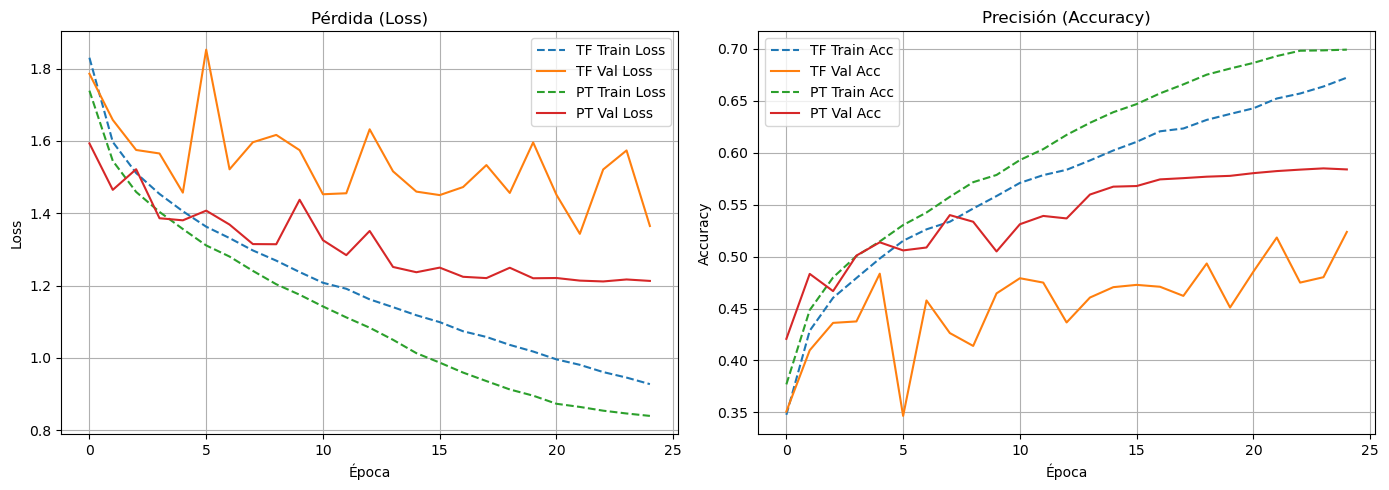

In [6]:
plt.figure(figsize=(14, 5))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(history_tf.history['loss'], label='TF Train Loss', linestyle='--')
plt.plot(history_tf.history['val_loss'], label='TF Val Loss')
plt.plot(history_pt['train_loss'], label='PT Train Loss', linestyle='--')
plt.plot(history_pt['val_loss'], label='PT Val Loss')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Precisión
plt.subplot(1, 2, 2)
plt.plot(history_tf.history['accuracy'], label='TF Train Acc', linestyle='--')
plt.plot(history_tf.history['val_accuracy'], label='TF Val Acc')
plt.plot(history_pt['train_acc'], label='PT Train Acc', linestyle='--')
plt.plot(history_pt['val_acc'], label='PT Val Acc')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

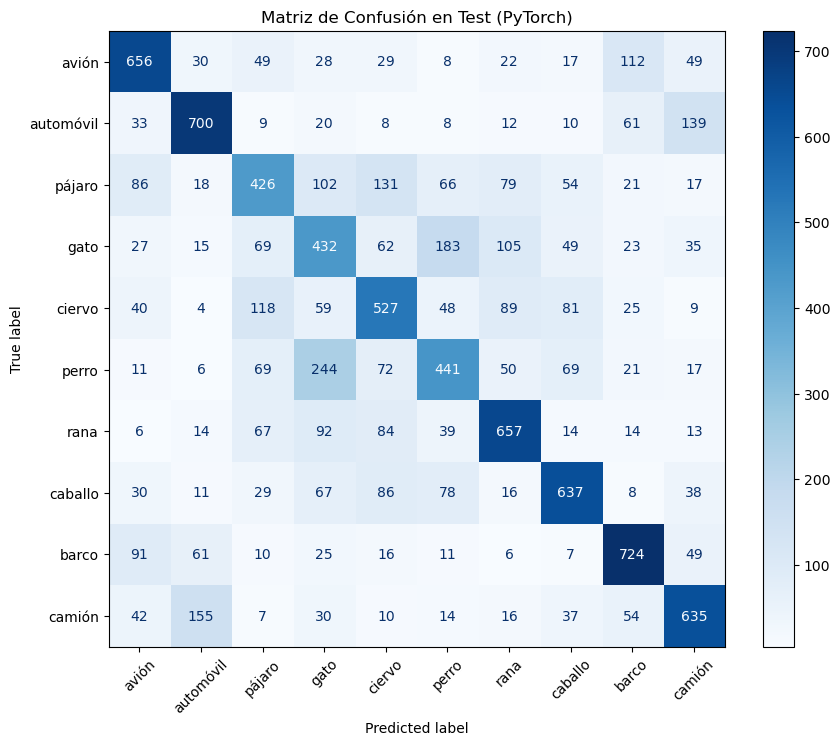

Pares de clases que más se confunden frecuentemente:
 - Clase real 'perro' clasificada como 'gato': 244 veces
 - Clase real 'gato' clasificada como 'perro': 183 veces
 - Clase real 'camión' clasificada como 'automóvil': 155 veces
 - Clase real 'automóvil' clasificada como 'camión': 139 veces
 - Clase real 'pájaro' clasificada como 'ciervo': 131 veces


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de confusión
cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Matriz de Confusión en Test (PyTorch)')
plt.show()

# Identificar las clases que más se confunden (excluyendo la diagonal principal)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
max_confusions = np.unravel_index(np.argsort(cm_no_diag.ravel())[-5:], cm_no_diag.shape)

print("Pares de clases que más se confunden frecuentemente:")
for i in reversed(range(5)):
    c_true = class_names[max_confusions[0][i]]
    c_pred = class_names[max_confusions[1][i]]
    count = cm_no_diag[max_confusions[0][i], max_confusions[1][i]]
    print(f" - Clase real '{c_true}' clasificada como '{c_pred}': {count} veces")